# Ignore this part and go down to inference part

In [2]:
import json
import os
import time
import traceback
import typing
from datetime import datetime
from pathlib import Path

import lightning as L
import torch
from dotenv import load_dotenv
from lightning.fabric import Fabric
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger, WandbLogger
from pytorch_toolbelt.utils import count_parameters, transfer_weights, is_dist_avail_and_initialized
from transformers import (
    HfArgumentParser,
)

from cryoet.data.detection.data_module import ObjectDetectionDataModule_sim
from cryoet.ensembling import average_checkpoints, trace_model_and_save
from cryoet.modelling.detection.convnext import ConvNextForObjectDetectionConfig, ConvNextForObjectDetection
from cryoet.modelling.detection.dynunet import DynUNetForObjectDetectionConfig, DynUNetForObjectDetection
from cryoet.modelling.detection.litehrnet import HRNetv2ForObjectDetection, HRNetv2ForObjectDetectionConfig
from cryoet.modelling.detection.segresnet_object_detection_s1 import (
    SegResNetForObjectDetectionS1,
    SegResNetForObjectDetectionS1Config,
)
from cryoet.modelling.detection.segresnet_object_detection_v2 import (
    SegResNetForObjectDetectionV2,
    SegResNetForObjectDetectionV2Config,
)
from cryoet.training.args import MyTrainingArguments, ModelArguments, DataArguments
from cryoet.training.ema import BetaDecay, EMACallback
from cryoet.training.object_detection_module import ObjectDetectionModel

/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def build_model_name_slug(data_args, model_args, training_args):
    num_classes = 6 if model_args.use_6_classes else 5
    model_name_slug = f"{model_args.model_name}_fold_{data_args.fold}_{num_classes}x{model_args.train_depth_window_size}x{model_args.train_spatial_window_size}x{model_args.train_spatial_window_size}"
    if data_args.normalization != "minmax":
        model_name_slug += f"_{data_args.normalization}"
    if data_args.use_sliding_crops:
        model_name_slug += "_sc"
    if data_args.use_random_crops:
        model_name_slug += "_rc"
    if data_args.use_instance_crops:
        model_name_slug += "_ic"
    if model_args.use_stride2:
        model_name_slug += "_s2"
    if model_args.use_stride4:
        model_name_slug += "_s4"
    if not model_args.use_centernet_nms:
        model_name_slug += "_no_nms"
    if not model_args.use_offset_head:
        model_name_slug += "_no_offset"
    if model_args.use_single_label_per_anchor:
        model_name_slug += "_slpa"
    if data_args.train_modes != "denoised":
        model_name_slug += "_" + data_args.train_modes.replace(",", "_")
    if data_args.copy_paste_prob > 0:
        model_name_slug += f"_copy_{data_args.copy_paste_prob}x{data_args.copy_paste_limit}"
    if data_args.random_erase_prob > 0:
        model_name_slug += f"_re_{data_args.random_erase_prob}"
    if data_args.mixup_prob > 0:
        model_name_slug += f"_mixup_{data_args.mixup_prob}"
    if model_args.use_cross_entropy_loss:
        model_name_slug += "_ce"

    return f"{training_args.version_prefix}{model_name_slug}"

In [3]:
def create_model_from_args(model_args, training_args):
    num_classes = 6 if model_args.use_6_classes else 5
    if model_args.model_name == "segresnet_s1":
        config = SegResNetForObjectDetectionS1Config(
            num_classes=num_classes,
        )
        model = SegResNetForObjectDetectionS1(config)
    elif model_args.model_name == "segresnetv2":
        config = SegResNetForObjectDetectionV2Config(
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            use_offset_head=model_args.use_offset_head,
            head_dropout_prob=model_args.head_dropout_prob,
            num_classes=num_classes,
        )
        model = SegResNetForObjectDetectionV2(config)
    elif model_args.model_name == "dynunet":
        config = DynUNetForObjectDetectionConfig(
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            num_classes=num_classes,
        )
        model = DynUNetForObjectDetection(config)
    elif model_args.model_name == "dynunet_v2":
        config = DynUNetForObjectDetectionConfig(
            # dropout=0.1,
            res_block=True,
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            num_classes=num_classes,
            object_size=32,
            intermediate_channels=64,
            offset_intermediate_channels=8,
        )
        model = DynUNetForObjectDetection(config)
    elif model_args.model_name == "hrnet":
        config = HRNetv2ForObjectDetectionConfig(
            num_classes=num_classes,
        )
        model = HRNetv2ForObjectDetection(config)
    elif model_args.model_name == "convnext":
        config = ConvNextForObjectDetectionConfig(
            num_classes=num_classes,
        )
        model = ConvNextForObjectDetection(config)
    # elif model_args.model_name == "unet3d":
    #     config = UNet3DForObjectDetectionConfig(window_size=model_args.window_size)
    #     model = UNet3DForObjectDetection(config)
    # elif model_args.model_name == "maxvit_nano_unet25d":
    #     config = MaxVitUnet25dConfig(img_size=model_args.window_size)
    #     model = MaxVitUnet25d(config)
    # elif model_args.model_name == "unet3d-fat":
    #     config = UNet3DForObjectDetectionConfig(
    #         encoder_channels=[32, 64, 128, 256],
    #         num_blocks_per_stage=(2, 3, 4, 6),
    #         num_blocks_per_decoder_stage=(2, 2, 2),
    #         intermediate_channels=64,
    #         offset_intermediate_channels=16,
    #         window_size=model_args.window_size,
    #     )
    #     model = UNet3DForObjectDetection(config)
    # elif model_args.model_name == "unetr":
    #     config = SwinUNETRForObjectDetectionConfig()
    #     model = SwinUNETRForObjectDetection(config)
    else:
        raise ValueError(f"Unknown model name: {model_args.model_name}")
    if model_args.pretrained_backbone_path is not None:
        backbone_sd = torch.load(model_args.pretrained_backbone_path, weights_only=True)
        model.backbone.load_state_dict(backbone_sd, strict=True)
        training_args.master_print(f"Loaded pretrained backbone from {model_args.pretrained_backbone_path}")
    return model

In [4]:
def infer_training_precision(training_args):
    if training_args.bf16:
        return "bf16-mixed"
    if training_args.fp16:
        return "16-mixed"
    return 32

In [5]:
def infer_strategy(training_args, fabric):
    if fabric.world_size > 1:
        if training_args.ddp_find_unused_parameters:
            strategy = "ddp_find_unused_parameters_true"
        else:
            strategy = "ddp"
    else:
        strategy = "auto"
    return strategy

In [3]:
training_args=MyTrainingArguments()

In [4]:
training_args

MyTrainingArguments(output_dir='trainer_output', overwrite_output_dir=False, do_train=False, do_eval=True, do_predict=False, eval_strategy=<IntervalStrategy.EPOCH: 'epoch'>, prediction_loss_only=False, per_device_train_batch_size=8, per_device_eval_batch_size=1, per_gpu_train_batch_size=None, per_gpu_eval_batch_size=None, gradient_accumulation_steps=1, eval_accumulation_steps=None, eval_delay=0, torch_empty_cache_steps=None, learning_rate=5e-05, weight_decay=0.0001, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=3.0, num_train_epochs=3.0, max_steps=-1, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs={}, warmup_ratio=0.0, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir='trainer_output/runs/Oct14_16-57-25_m24008-lin', logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=1, logging_nan_inf_filter=True, save_strategy=<SaveStrategy.EPOCH: 'epoch'>, save_st

In [5]:
model_args = ModelArguments()

In [6]:
data_args = DataArguments()

In [7]:
data_args

DataArguments(data_root=None, fold=0, interpolation_mode='1', split_strategy='split_data_into_folds', normalization='minmax', use_sliding_crops=False, use_random_crops=False, use_instance_crops=False, use_random_flips=True, train_modes='wbp', valid_modes='wbp', num_crops_per_study=256, scale_limit=0.05, anisotropic_scale_limit=0.0, z_rotation_limit=360.0, y_rotation_limit=0.0, x_rotation_limit=0.0, random_erase_prob=0.0, copy_paste_prob=0.0, copy_paste_limit=1, mixup_prob=0.0, gaussian_noise_sigma=0.0, use_weighted_average=False, validate_on_z_flips=False, validate_on_y_flips=False, validate_on_x_flips=False, validate_on_rot90=False)

In [8]:
training_args = typing.cast(MyTrainingArguments, training_args)
model_args = typing.cast(ModelArguments, model_args)
data_args = typing.cast(DataArguments, data_args)

In [12]:
training_args.adam_beta1 = 0.95
training_args.adam_beta2 = 0.99
training_args.average_tokens_across_devices=True
training_args.dataloader_num_workers=8
training_args.dataloader_persistent_workers=True
training_args.dataloader_pin_memory=True
training_args.ddp_find_unused_parameters=True
training_args.early_stopping=15
data_args.fold=0
training_args.learning_rate=5e-5
training_args.max_grad_norm=3
training_args.ddp_find_unused_parameters=True
model_args.model_name='segresnetv2'
training_args.num_train_epochs=75
training_args.per_device_train_batch_size=2
model_args.pretrained_backbone_path = 'pretrained/wholeBody_ct_segmentation/models/model.pt'
data_args.scale_limit = 0.05
model_args.use_6_classes = True
data_args.use_instance_crops=True
data_args.use_random_crops=True
model_args.use_stride4 = False
training_args.warmup_steps = 64
training_args.weight_decay = 0.01
data_args.y_rotation_limit=5
data_args.x_rotation_limit=5
training_args.seed=1
data_args.interpolation_mode=1
data_args.validate_on_rot90 = True

In [13]:
model_name_slug = build_model_name_slug(data_args, model_args, training_args)

In [14]:
model_name_slug

'segresnetv2_fold_0_6x96x128x128_rc_ic_s2'

In [15]:
timestamp = datetime.now().strftime("%y%m%d_%H%M")

In [16]:
if training_args.output_dir == 'trainer_output':
        output_dir_name = f"runs/{model_name_slug}"

        training_args_str = f"{training_args.optim.value}_lr_{training_args.learning_rate:.0e}_wd_{training_args.weight_decay}_b1_{training_args.adam_beta1}_b2_{training_args.adam_beta2}"
        if training_args.ema:
            training_args_str += f"_ema_{training_args.ema_decay}_{training_args.ema_beta}"

        training_args.output_dir = os.path.join(output_dir_name, f"{timestamp}_{training_args_str}")

In [17]:
model_args

ModelArguments(model_name='segresnetv2', pretrained_model_name_or_path=None, pretrained_backbone_path='pretrained/wholeBody_ct_segmentation/models/model.pt', use_qfl_loss=False, train_spatial_window_size=128, train_depth_window_size=96, valid_depth_window_size=192, valid_depth_num_tiles=1, valid_spatial_window_size=128, valid_spatial_num_tiles=7, use_centernet_nms=True, use_single_label_per_anchor=False, use_offset_head=True, use_stride4=False, use_stride2=True, use_6_classes=True, assigned_min_iou_for_anchor=0.05, assigner_max_anchors_per_point=13, assigner_alpha=1.0, assigner_beta=6.0, apply_loss_on_each_stride=False, head_dropout_prob=0.0, use_varifocal_loss=True, use_cross_entropy_loss=False)

In [18]:
training_args.master_print(f"Training arguments: {training_args}")

Training arguments: MyTrainingArguments(
_n_gpu=2,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.95,
adam_beta2=0.99,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=8,
dataloader_persistent_workers=True,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=True,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
early_stopping=15,
ema=False,
ema_beta=10,
ema_decay=0.995,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval

In [19]:
model = create_model_from_args(model_args, training_args)

Loaded pretrained backbone from pretrained/wholeBody_ct_segmentation/models/model.pt


In [20]:
training_args.master_print(f"Model parameters: {count_parameters(model, human_friendly=True)}")

Model parameters: {'total': '19.0M', 'trainable': '19.0M', 'backbone': '18.8M', 'dropout': '0', 'head2': '180.19K'}


In [ ]:
data_args = DataArguments()
data_args.data_root = '/mnt/data2/D2/OD/Data'

In [123]:
data_args.use_instance_crops = True
data_args.use_random_crops = True

In [128]:
fabric = Fabric()
with fabric.rank_zero_first():
            data_module = ObjectDetectionDataModule_sim(
                data_args=data_args,
                train_args=training_args,
                model_args=model_args,
            )

In [135]:
data_module.valid_studies_original

['TS_81_1',
 'TS_76_8',
 'TS_99_9',
 'TS_100_3',
 'TS_87_5',
 'TS_81_4',
 'TS_94_3',
 'TS_101_5',
 'TS_91_7',
 'TS_103_4',
 'TS_71_8',
 'TS_71_3',
 'TS_91_9',
 'TS_86_9',
 'TS_71_7',
 'TS_80_5',
 'TS_70_8',
 'TS_5_4',
 'TS_87_7',
 'TS_86_8',
 'TS_87_6',
 'TS_80_8',
 'TS_69_2',
 'TS_79_4',
 'TS_98_4',
 'TS_102_2',
 'TS_94_5',
 'TS_93_9',
 'TS_87_4',
 'TS_70_9',
 'TS_73_6',
 'TS_93_5']

In [25]:
model_module = ObjectDetectionModel(model=model, data_args=data_args, model_args=model_args, train_args=training_args)

In [26]:
if training_args.transfer_weights is not None:
            checkpoint = torch.load(training_args.transfer_weights, map_location="cpu")
            transfer_weights(model_module, checkpoint["state_dict"])
            training_args.master_print(f"Loaded weights from {training_args.transfer_weights}")

In [27]:
checkpoint_callback = ModelCheckpoint(
            dirpath=training_args.output_dir,
            enable_version_counter=False,
            monitor="val/score",
            mode="max",
            save_last=True,
            auto_insert_metric_name=False,
            save_top_k=5,
            filename=f"{timestamp}_{model_name_slug}"
            + "_{step:03d}-score-{val/score:0.4f}-at-{val/apo-ferritin_threshold:0.3f}-{val/beta-galactosidase_threshold:0.3f}-{val/ribosome_threshold:0.3f}-{val/thyroglobulin_threshold:0.3f}-{val/virus-like-particle_threshold:0.3f}",
            # + "_{step:03d}-score-{val/score:0.4f}",
        )

In [28]:
report_to = training_args.report_to
if isinstance(report_to, list) and len(report_to) == 1:
            report_to = report_to[0]

In [29]:
report_to

'tensorboard'

In [30]:
loggers = []
if "tensorboard" in report_to:
            logger = TensorBoardLogger(save_dir=training_args.output_dir, name=None, version="")
            loggers.append(logger)
if "wandb" in report_to:
            logger = WandbLogger()
            loggers.append(logger)
if len(loggers) == 1:
            loggers = loggers[0]

In [31]:
loggers

In [32]:
callbacks = [checkpoint_callback]

In [33]:
if training_args.early_stopping > 0:
            callbacks.append(
                EarlyStopping(monitor="val/score", min_delta=0.001, patience=training_args.early_stopping, mode="max")
            )

In [34]:
callbacks

In [35]:
lr_monitor = LearningRateMonitor(logging_interval="step")
if "wandb" not in training_args.report_to:
            callbacks.append(lr_monitor)

precision = infer_training_precision(training_args)
fabric.print(f"Training precision: {precision}")

Training precision: bf16-mixed


In [36]:
if training_args.ema:
            callbacks.append(EMACallback(decay=BetaDecay(max_decay=training_args.ema_decay, beta=training_args.ema_beta)))
            fabric.print(f"Using EMA with decay={training_args.ema_decay} and beta={training_args.ema_beta}")

fabric.print("Batch Size:", training_args.per_device_train_batch_size, training_args.per_device_eval_batch_size)

Batch Size: 2 1


In [37]:
strategy = infer_strategy(training_args, fabric)

In [38]:
strategy

'auto'

In [39]:
trainer = L.Trainer(
            strategy=strategy,
            max_epochs=int(training_args.num_train_epochs),
            max_steps=training_args.max_steps,
            precision=precision,
            log_every_n_steps=training_args.logging_steps,
            default_root_dir=training_args.output_dir,
            callbacks=callbacks,
            accumulate_grad_batches=training_args.gradient_accumulation_steps,
            gradient_clip_val=training_args.max_grad_norm,
            logger=loggers,
        )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model_module, datamodule=data_module)

Flipping False False False
Added TS_5_4_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False


/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/yousef.metwally/Kaggle-2024-CryoET/runs/segresnetv2_fold_0_6x96x128x128_rc_ic_s2/250528_1518_adamw_torch_lr_5e-05_wd_0.01_b1_0.95_b2_0.99 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Added TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Validation studies: ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False']
Using warmup steps: 64



  | Name  | Type                          | Params | Mode 
----------------------------------------------------------------
0 | model | SegResNetForObjectDetectionV2 | 19.0 M | train
----------------------------------------------------------------
19.0 M    Trainable params
0         Non-trainable params
19.0 M    Total params
75.918    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.84it/s]Rank 0 got local studies ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False']
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Rank 0 has 0 predictions
Rank 0 has 0 predictions after all_gather
Epoch 0: 100%|██████████| 1280/1280 [08:03<00:00,  2.65it/s, train/loss_step=1.140, train/cls_loss_step=1.120, train/reg_loss_step=0.0253, t


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

: 

In [9]:
data_args = DataArguments()
data_args.data_root = '/mnt/data2/D2/OD/Data'

In [10]:
fabric = Fabric()
with fabric.rank_zero_first():
            data_module = ObjectDetectionDataModule_sim(
                data_args=data_args,
                train_args=training_args,
                model_args=model_args,
            )

Fabric will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Fabric(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


In [11]:
data_args.use_instance_crops = True
data_args.use_random_crops = True

In [12]:
import torch
from cryoet.ensembling import model_from_checkpoint

# === 1. Load checkpoint ===
ckpt_path = "/home/yousef.metwally/Kaggle-2024-CryoET/trainer_output/250915_1007_segresnetv2_fold_0_6x96x128x128_rc_ic_s2_wbp_270336-valloss-0.6543.ckpt"
num_classes = 1

# Select GPU 1 explicitly
device = torch.device("cuda:1")

# Load model
model = model_from_checkpoint(ckpt_path, num_classes=num_classes, use_stride2=True, use_stride4=False)
model = model.eval().to(device)



# Get first batch (just one tomo for now)



In [221]:
model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_radius.jit')
model.eval().cuda()

RecursiveScriptModule(
  original_name=Ensemble
  (models): RecursiveScriptModule(
    original_name=ModuleList
    (0): RecursiveScriptModule(
      original_name=SegResNetForObjectDetectionV2
      (backbone): RecursiveScriptModule(
        original_name=SegResNetBackbone
        (act_mod): RecursiveScriptModule(original_name=ReLU)
        (convInit): RecursiveScriptModule(
          original_name=Convolution
          (conv): RecursiveScriptModule(original_name=Conv3d)
        )
        (down_layers): RecursiveScriptModule(
          original_name=ModuleList
          (0): RecursiveScriptModule(
            original_name=Sequential
            (0): RecursiveScriptModule(original_name=Identity)
            (1): RecursiveScriptModule(
              original_name=ResBlock
              (norm1): RecursiveScriptModule(original_name=GroupNorm)
              (norm2): RecursiveScriptModule(original_name=GroupNorm)
              (act): RecursiveScriptModule(original_name=ReLU)
              

In [13]:
data_module.setup("validate")
val_loader = data_module.val_dataloader()

len(val_loader)

num train_samples 256
num valid_samples 32
Flipping False False False
Added TS_81_1 objects to the dataset
Flipping False False False
Added TS_76_8 objects to the dataset
Flipping False False False
Added TS_99_9 objects to the dataset
Flipping False False False
Added TS_100_3 objects to the dataset
Flipping False False False
Added TS_87_5 objects to the dataset
Flipping False False False
Added TS_81_4 objects to the dataset
Flipping False False False
Added TS_94_3 objects to the dataset
Flipping False False False
Added TS_101_5 objects to the dataset
Flipping False False False
Added TS_91_7 objects to the dataset
Flipping False False False
Added TS_103_4 objects to the dataset
Flipping False False False
Added TS_71_8 objects to the dataset
Flipping False False False
Added TS_71_3 objects to the dataset
Flipping False False False
Added TS_91_9 objects to the dataset
Flipping False False False
Added TS_86_9 objects to the dataset
Flipping False False False
Added TS_71_7 objects to the da

288

In [12]:
%load_ext autoreload
%autoreload 2

batch = next(iter(val_loader))

volume = batch["volume"].cuda()
print(volume.shape)
labels = batch["labels"].cuda()
print(labels.shape)
print(labels)
print(batch["study"])
# === 3. Run model with labels to get losses ===
with torch.no_grad():
    output = model(volume, labels=labels, apply_loss_on_each_stride=True)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch.Size([1, 1, 96, 128, 128])
torch.Size([1, 2, 5])
tensor([[[ 63.5000,  63.5000,  47.5000,   0.0000,   6.6918],
         [118.1548,  62.9074,  32.1987,   0.0000,   5.7358]]], device='cuda:0')
['TS_81_1']
tensor([[[[[12.4817, 11.3896, 13.4089,  ..., 16.6934, 15.5498, 17.7861],
           [12.1321, 11.6331, 15.5586,  ..., 17.7983, 15.3254, 17.0421],
           [15.2410, 16.0942, 21.0091,  ..., 19.4865, 16.0327, 17.8736],
           ...,
           [12.9546, 12.1944, 12.6538,  ..., 17.1173, 13.5830, 15.4213],
           [14.3124, 12.8598, 12.8518,  ..., 14.9362, 12.7275, 15.5893],
           [17.4255, 14.1267, 13.9824,  ..., 14.9807, 13.9438, 17.4875]],

          [[ 9.1764,  8.8005, 10.9942,  ..., 14.8842, 13.2545, 14.5545],
           [ 8.7840,  9.4243, 13.5336,  ..., 16.2144, 12.9687, 13.3755],
           [11.4611, 13.4191, 19.4171,  ..., 17.5371, 13.2681, 13.8109],
           ...,
           [1

In [216]:
# === 4. Inspect ===
logits = output.logits
print(logits[0].shape)
loss = output.loss
print(loss)

torch.Size([1, 1, 96, 64, 64])
tensor(0.8878, device='cuda:0')


In [217]:
loss_dict = output.loss_dict
loss_dict

{'loss': 0.8877963423728943,
 'cls_loss': 0.7620412707328796,
 'reg_loss': 0.11878247559070587,
 'rad_loss': 0.006972637493163347,
 'num_items_in_batch': 4.403073787689209}

In [ ]:
print(batch["study"])

['TS_76_8']


In [73]:
print(type(batch["study"][0]))

<class 'str'>


In [ ]:
with torch.no_grad():
    for batch in val_loader:
        print(1)

In [ ]:
import torch
from torch import autocast

# === 0. Device setup ===
device = torch.device("cuda:1")
torch.cuda.set_device(device)
torch.cuda.empty_cache()

# === 1. Model setup ===
model = model.to(device).eval()

val_losses = []
cls_losses = []
reg_losses = []
rad_losses = []

i = 0
with torch.no_grad():
    for batch in val_loader:
        # Optional condition for filtering studies
        if batch["study"][0] != 'TS_81_1':
            break

        # Move data to GPU 1
        volume = batch["volume"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        print(f"Processing study: {batch['study'][0]}")
        print(labels)
        i += 1

        # === 2. Mixed precision inference ===
        with autocast(device_type='cuda', dtype=torch.float16):
            output = model(volume, labels=labels, apply_loss_on_each_stride=True)

        # === 3. Extract and store losses ===
        loss_dict = output.loss_dict
        val_losses.append(loss_dict["loss"])
        cls_losses.append(loss_dict["cls_loss"])
        reg_losses.append(loss_dict["reg_loss"])
        rad_losses.append(loss_dict["rad_loss"])

        # === 4. Clean up GPU memory each iteration ===
        del volume, labels, output, loss_dict
        torch.cuda.empty_cache()

# === 5. Compute averages ===
mean_val_loss = sum(val_losses) / len(val_losses)
mean_cls_loss = sum(cls_losses) / len(cls_losses)
mean_reg_loss = sum(reg_losses) / len(reg_losses)
mean_rad_loss = sum(rad_losses) / len(rad_losses)

print(f"\nValidation loss: {mean_val_loss:.4f}")
print(f"  cls_loss: {mean_cls_loss:.4f}")
print(f"  reg_loss: {mean_reg_loss:.4f}")
print(f"  rad_loss: {mean_rad_loss:.4f}")


(184, 256, 256)
Processing study: TS_81_1
tensor([[[[[16.3125, 16.5938, 19.7344,  ..., 13.2812, 13.7188, 16.0000],
           [15.0156, 16.8281, 22.9062,  ..., 13.7656, 13.4062, 15.6875],
           [15.2578, 18.3281, 26.6406,  ..., 17.0312, 15.1641, 17.2656],
           ...,
           [15.7500, 15.9688, 19.4219,  ..., 16.0312, 13.4766, 15.8672],
           [14.3281, 13.4297, 14.4922,  ..., 14.2109, 12.5469, 15.3281],
           [15.6953, 13.5000, 13.9766,  ..., 14.6484, 13.6094, 17.1562]],

          [[11.8359, 12.8906, 16.4375,  ..., 12.4688, 12.3281, 13.5000],
           [ 9.7266, 11.4922, 18.0000,  ..., 13.8203, 12.6562, 13.1094],
           [ 9.4766, 11.9141, 20.0312,  ..., 17.2656, 14.0000, 14.6016],
           ...,
           [13.7812, 14.4922, 16.6562,  ..., 13.6562, 10.7266, 11.3828],
           [12.4297, 12.2812, 12.4453,  ..., 11.3906,  9.6562, 11.1875],
           [13.0469, 11.5391, 11.3594,  ..., 11.4141, 10.6406, 13.8281]],

          [[10.9219, 11.8984, 15.4453,  ..., 1

In [141]:
mean_val_loss = sum(val_losses) / len(val_losses)
mean_cls_loss = sum(cls_losses) / len(cls_losses)
mean_reg_loss = sum(reg_losses) / len(reg_losses)
mean_rad_loss = sum(rad_losses) / len(rad_losses)

print(f"Validation loss: {mean_val_loss:.4f}")
print(f"  cls_loss: {mean_cls_loss:.4f}")
print(f"  reg_loss: {mean_reg_loss:.4f}")
print(f"  rad_loss: {mean_rad_loss:.4f}")


Validation loss: 1.7973
  cls_loss: 1.6922
  reg_loss: 0.0864
  rad_loss: 0.0188


In [142]:
i

49

In [95]:
data_module.setup(0)

Flipping False False False
SlidingWindowCryoETObjectDetectionDataset (184, 630, 630) (192, 128, 128) (1, 7, 7)
compute_better_tiles_with_num_til 192 128 128
compute_better_tiles_with_num_til 1 7 7
compute_better_tiles_with_num_til 184 630 630
Added TS_5_4_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
SlidingWindowCryoETObjectDetectionDataset (184, 630, 630) (192, 128, 128) (1, 7, 7)
compute_better_tiles_with_num_til 192 128 128
compute_better_tiles_with_num_til 1 7 7
compute_better_tiles_with_num_til 184 630 630
Added TS_69_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Validation studies: ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False']


In [50]:
valloader = data_module.val_dataloader()

In [51]:
valbatch = next(iter(valloader))

In [52]:
valbatch['volume'].shape

torch.Size([1, 1, 192, 128, 128])

# Here starts the inference sooryyy xD

In [2]:
# inference
from ctypes import *

import os
import torch
import dataclasses
import zarr
import math

from collections import defaultdict
from pathlib import Path
from fire import Fire

import numpy as np
import pandas as pd
import torch.jit
from tqdm import tqdm

import typing
import einops

from torch import Tensor, nn
from typing import List, Tuple, Union, Any, Iterable, Optional
from torch.utils.data import Dataset, DataLoader
import onnxruntime as ort

In [3]:
import torch
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/all_ensemble.jit')
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/sim_ensemble.jit')
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/wbp_ensemble.jit')
model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_ensemble.jit')
model.eval()
models = [model]

In [121]:
import torch
from cryoet.ensembling import model_from_checkpoint


# === 1. Load checkpoint ===
ckpt_path = "/home/yousef.metwally/Kaggle-2024-CryoET/trainer_output/250915_1007_segresnetv2_fold_0_6x96x128x128_rc_ic_s2_wbp_270336-valloss-0.6543.ckpt"
num_classes = 1
model = model_from_checkpoint(ckpt_path, num_classes=num_classes, use_stride2=True, use_stride4=False)
model = model.eval().cuda()
model = model.half()
models = [model]

In [4]:
import mrcfile
def get_volume_mrc(v_path):
    with mrcfile.open(v_path, permissive=True) as mrc:
        tomo_array = mrc.data.astype(np.float32)

    return(tomo_array)

In [29]:
#volume = get_volume_mrc('/mnt/billy/abt3/group/agraunser/transfer/Thorsten/topick/01122021_BrnoKrios_arctis_lam3_pos27.mrc')
#volume = get_volume_mrc('/mnt/data2/D2/generalization_tomogram/tiltseries_rec_lp60.mrc')
#volume = get_volume_mrc('/mnt/data2/D2/public_czi_tomos_denoised/TS_81_1.mrc')
#volume = get_volume_mrc('/mnt/billy/abt3/group/agraunser/transfer/Gavin/OD/test_od/Jun30_model/Position_5_6_EVN_Vol/Position_5_6_EVN_Vol.mrc')
volume = get_volume_mrc('/mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/simulations/2022_05_simulations/tomo_simulation_gen_3_dense/500/reconstruction/tiltseries_rec.mrc')

In [30]:
volume.shape

(200, 512, 512)

In [ ]:
tomo = 'gen3'

In [31]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from cryoet.inference.predict_volume import *
import math

submissions = []
output_strides = (2,)
window_size = (256 , 296, 296)
tiles_per_dim = ( 1 #math.ceil(volume.shape[0]*1/window_size[0])  
                 ,math.ceil(volume.shape[1]*1/window_size[1]),
                 math.ceil(volume.shape[2]*1/window_size[2]))
#print(tiles_per_dim)
#tiles_per_dim=(1,9,9)
use_weighted_average = True
use_centernet_nms = True
use_single_label_per_anchor = False
pre_nms_top_k = 16536*5
use_z_flip_tta = False
use_y_flip_tta = False
use_x_flip_tta = False
score_thresholds=[0.255,0.235,0.16 ,0.205,0.225, 0.5]
iou_threshold = 0.85
num_workers = 0
torch_dtype = torch.float16
#torch_dtype = torch.float32
device = 'cuda'
batch_size = 1
tomo = 'gen3_dense'
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
study_sub = predict_volume(
            volume=volume,
            study_name=tomo,
            output_strides=output_strides,
            models= models,
            window_size=window_size,
            tiles_per_dim=tiles_per_dim,
            use_weighted_average=use_weighted_average,
            use_centernet_nms=use_centernet_nms,
            use_single_label_per_anchor=use_single_label_per_anchor,
            pre_nms_top_k=None,

            use_z_flip_tta=use_z_flip_tta,
            use_y_flip_tta=use_y_flip_tta,
            use_x_flip_tta=use_x_flip_tta,

            score_thresholds=[0.005],
            iou_threshold=0.6,
            sigma= (0,16,16),
            batch_size=batch_size,
            num_workers=num_workers,

            device=device,
            torch_dtype=torch_dtype,
        )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
4
tiles: 
(slice(0, 200, None), slice(0, 296, None), slice(0, 296, None))
(slice(0, 200, None), slice(0, 296, None), slice(280, 512, None))
(slice(0, 200, None), slice(280, 512, None), slice(0, 296, None))
(slice(0, 200, None), slice(280, 512, None), slice(280, 512, None))


gen3_dense (200, 512, 512):   0%|          | 0/4 [00:00<?, ?it/s]

padding z y x :  56 0 0
(256, 296, 296)


gen3_dense (200, 512, 512):  25%|██▌       | 1/4 [00:00<00:00,  8.76it/s]

Num classes 1
I am in  post_init
weight_tensors torch.Size([128, 148, 148])
len(self.scores) 1
scores.shape:  torch.Size([1, 128, 148, 148])
roi (slice(tensor(0), tensor(128), None), slice(tensor(0), tensor(148), None), slice(tensor(0), tensor(148), None))
self.scores[i].shape torch.Size([1, 100, 256, 256])
scores_view.shape:  torch.Size([1, 100, 148, 148])
padding z y x :  56 0 64
(256, 296, 296)


gen3_dense (200, 512, 512): 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]

len(self.scores) 1
scores.shape:  torch.Size([1, 128, 148, 148])
roi (slice(tensor(0), tensor(128), None), slice(tensor(0), tensor(148), None), slice(tensor(140), tensor(288), None))
self.scores[i].shape torch.Size([1, 100, 256, 256])
scores_view.shape:  torch.Size([1, 100, 148, 116])
padding z y x :  56 64 0
(256, 296, 296)
len(self.scores) 1
scores.shape:  torch.Size([1, 128, 148, 148])
roi (slice(tensor(0), tensor(128), None), slice(tensor(140), tensor(288), None), slice(tensor(0), tensor(148), None))
self.scores[i].shape torch.Size([1, 100, 256, 256])
scores_view.shape:  torch.Size([1, 100, 116, 148])
padding z y x :  56 64 64
(256, 296, 296)
len(self.scores) 1
scores.shape:  torch.Size([1, 128, 148, 148])
roi (slice(tensor(0), tensor(128), None), slice(tensor(140), tensor(288), None), slice(tensor(140), tensor(288), None))
self.scores[i].shape torch.Size([1, 100, 256, 256])
scores_view.shape:  torch.Size([1, 100, 116, 116])


52405
Predictions for class 0 after NMS 42082
Final predictions after NMS: 42082


In [32]:
study_sub

,experiment,particle_type,score,x,y,z
0,gen3_dense,apo-ferritin,0.992676,71.278320,301.373047,48.510254
1,gen3_dense,apo-ferritin,0.989258,252.920837,137.518555,105.280029
2,gen3_dense,apo-ferritin,0.989258,97.433838,183.327393,104.576416
3,gen3_dense,apo-ferritin,0.989258,96.946655,132.373535,116.839600
4,gen3_dense,apo-ferritin,0.989258,422.653320,480.076172,149.224976
...,...,...,...,...,...,...
42077,gen3_dense,apo-ferritin,0.005001,250.977432,335.073975,193.338379
42078,gen3_dense,apo-ferritin,0.005001,256.840942,505.105103,197.163086
42079,gen3_dense,apo-ferritin,0.005001,300.551514,67.145386,199.126343
42080,gen3_dense,apo-ferritin,0.005001,108.980621,177.309814,199.179443


In [126]:
# make locate file from submission
submission = study_sub.copy()
submission = submission.drop('experiment', axis=1)
submission = submission.rename(columns={
    "x": "X", "y": "Y", "z": "Z",
    "score": "metric_best", "particle_type": "predicted_class"
})
submission["boxsize"] = submission["size"]
submission["predicted_class"] = 0
submission["width"] = submission['size']
submission["height"] = submission['size']
submission["depth"] = submission['size']

In [72]:
import pickle

# Load the .temb file
with open("/mnt/data2/D2/CZI_coords/round11_embeddings/TS_43_9/6SCJ_locate/located.tloc", "rb") as f:
    embeddings2 = pickle.load(f)

submission.attrs = embeddings2.attrs

In [74]:
submission.to_pickle(f"{tomo}_submission_06462.tloc")

In [127]:
submission

,predicted_class,metric_best,size,X,Y,Z,boxsize,width,height,depth
0,0,0.956543,7,529.672363,176.506104,84.999023,7,7,7,7
1,0,0.939453,12,355.970703,109.601074,20.432617,12,12,12,12
2,0,0.925293,12,276.089844,147.765625,14.480469,12,12,12,12
3,0,0.919434,14,555.082947,42.893799,40.323242,14,14,14,14
4,0,0.847168,21,298.645508,270.389648,72.114258,21,21,21,21
...,...,...,...,...,...,...,...,...,...,...
19594,0,0.005001,33,148.925781,134.881104,178.898499,33,33,33,33
19595,0,0.005001,32,443.011444,367.098206,179.906738,32,32,32,32
19596,0,0.005001,18,478.371094,374.660400,179.316650,18,18,18,18
19597,0,0.005001,27,446.916260,170.945465,180.855225,27,27,27,27


In [128]:
import pandas as pd
from scipy.spatial import KDTree
import numpy as np

solution = pd.read_csv('/mnt/data2/D2/CZI_coords/combined_embeddings_exp/alldatawithout_augmented/exp4/gt.csv')
solution = solution.drop_duplicates(subset=['experiment', 'x', 'y', 'z'])

In [129]:
import pandas as pd
from scipy.spatial import KDTree
import numpy as np

particle_radius = {
    'apo-ferritin': 6,
    'beta-amylase': 6.5,
    'beta-galactosidase': 9.0,
    'ribosome': 15.0,
    'thyroglobulin': 13.0,
    'virus-like-particle': 13.5,
}
for particle in solution['particle_type'].unique():
    
    ref_select = (solution['experiment'] == 'TS_81_1') & (solution['particle_type'] == particle)
    reference_points = solution.loc[ref_select, ['x', 'y', 'z']].values
    if reference_points.shape[0] == 0:
        continue
    cand_select = (submission['metric_best'] > 0.5)    
    candidate_points = submission.loc[cand_select, ['X', 'Y', 'Z']].values

    if candidate_points.shape[0] == 0:
            continue

    cand_tree = KDTree(candidate_points)

        # Query nearest candidate for each reference
    dists, indices = cand_tree.query(reference_points, k=1)  


        # Keep only those within particle radius
    matched_mask = dists <= particle_radius[particle]
    matched_candidates = set(indices[matched_mask])

        # Map back to dataframe indices
    cand_indices = submission.loc[cand_select].index

    matched_indices = [cand_indices[i] for i in matched_candidates]

        # Assign label
    submission.loc[matched_indices, 'predicted_class'] = particle


/tmp/ipykernel_2202571/2446277431.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ribosome' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.loc[matched_indices, 'predicted_class'] = particle


In [135]:
p = 'apo-ferritin'
#p = 'ribosome'
#p = 'virus-like-particle'
# x_min, x_max = 170, 177
# y_min, y_max = 380, 386
# z_min, z_max = 30, 37

filtered = submission[
    (submission["predicted_class"] == p) 
#    &
#     (submission["X"].between(x_min, x_max)) &
#     (submission["Y"].between(y_min, y_max)) &
#     (submission["Z"].between(z_min, z_max))
# 
]

In [136]:
filtered

,predicted_class,metric_best,size,X,Y,Z,boxsize,width,height,depth
20,apo-ferritin,0.701660,31,497.060516,263.915039,149.191284,31,31,31,31
56,apo-ferritin,0.573730,10,430.205078,137.152100,47.707031,10,10,10,10
58,apo-ferritin,0.572754,19,487.100586,272.463867,144.256836,19,19,19,19


In [137]:
submission[submission['predicted_class'] == p]['size'].mean()

20.0

In [ ]:
import pandas as pd
from scipy.spatial import KDTree
import numpy as np

particle_radius = {
    'apo-ferritin': 60,
    'beta-amylase': 65,
    'beta-galactosidase': 90,
    'ribosome': 150,
    'thyroglobulin': 130,
    'virus-like-particle': 135,
}

particle_color = {
    'apo-ferritin': 1,
    'beta-amylase': 2,
    'beta-galactosidase': 3,
    'ribosome': 4,
    'thyroglobulin': 5,
    'virus-like-particle': 6,
}


for particle in solution['particle_type'].unique():
    for exp in split_experiments:
        # Select reference points for this particle & experiment
        ref_select = (solution['experiment'] == exp) & (solution['particle_type'] == particle)
        reference_points = solution.loc[ref_select, ['x', 'y', 'z']].values
        if reference_points.shape[0] == 0:
            continue

        # Select candidate points
        #cand_select = (u['source_id'] == exp)
        #candidate_points = u.loc[cand_select, ['X', 'Y', 'Z']].values
        candidate_points = submission['X', 'Y', 'Z']
        if candidate_points.shape[0] == 0:
            continue

        cand_tree = KDTree(candidate_points)

        # Query nearest candidate for each reference
        dists, indices = cand_tree.query(reference_points, k=1)  

        # Keep only those within particle radius
        matched_mask = dists <= particle_radius[particle]
        matched_candidates = set(indices[matched_mask])

        # Map back to dataframe indices
        cand_indices = u.loc[cand_select].index
        matched_indices = [cand_indices[i] for i in matched_candidates]

        # Assign label
        u.loc[matched_indices, '32D_DBSCAN_label'] = particle_color[particle]

        print(
            particle, exp,
            "refs:", len(reference_points),
            "cands:", len(candidate_points),
            "matched:", len(matched_indices)
        )

,experiment,particle_type,score,size,x,y,z,predicted_class
0,TS_5_4_raw,apo-ferritin,0.970703,54,479.816406,493.650391,101.075500,0
1,TS_5_4_raw,apo-ferritin,0.965332,56,42.724609,311.380859,110.902649,0
2,TS_5_4_raw,apo-ferritin,0.963379,57,110.881775,442.179688,66.256836,0
3,TS_5_4_raw,apo-ferritin,0.960938,43,125.714844,545.770508,71.713867,0
4,TS_5_4_raw,apo-ferritin,0.959473,31,130.894958,452.301758,43.486328,0
...,...,...,...,...,...,...,...,...
27710,TS_5_4_raw,apo-ferritin,0.005001,67,492.986206,534.848633,180.770020,0
27711,TS_5_4_raw,apo-ferritin,0.005001,72,457.148193,542.903442,180.596924,0
27712,TS_5_4_raw,apo-ferritin,0.005001,69,401.037537,621.150024,180.686768,0
27713,TS_5_4_raw,apo-ferritin,0.005001,67,383.168823,273.191528,183.455811,0


In [21]:
score_thresholds = np.linspace(0,0.5,100)
picks = []
for i in score_thresholds:
    picks.append(len(study_sub[(study_sub['score']>i)]))
p = np.array(picks)
fst = np.gradient(p)
snd = np.gradient(fst)

4991


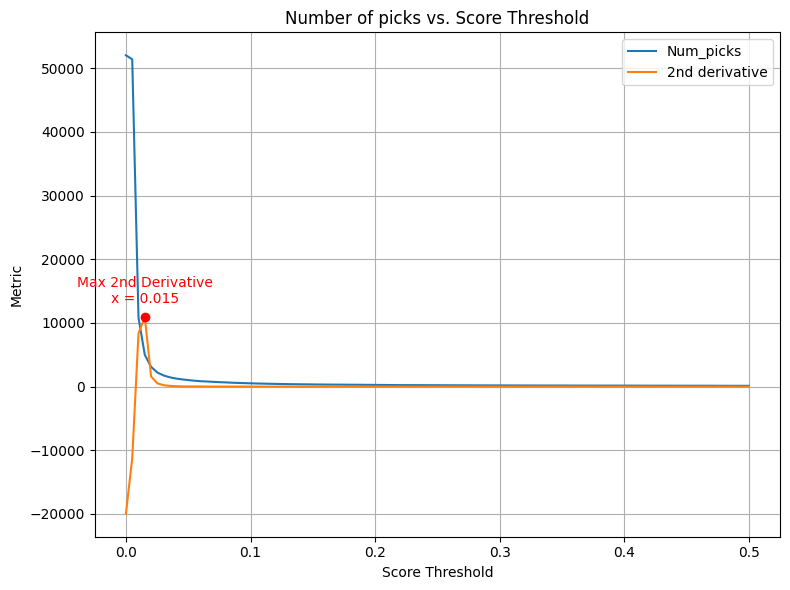

In [267]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'score_thresholds', 'picks', and 'snd' are already defined lists or arrays

# Find the index of the maximum second derivative
max_snd_idx = np.argmax(snd)
max_snd_value = snd[max_snd_idx]
corresponding_threshold = score_thresholds[max_snd_idx]
corresponding_picks = picks[max_snd_idx]
print(corresponding_picks)
# Plotting
plt.figure(figsize=(8,6))
plt.plot(score_thresholds, picks, label='Num_picks')
#plt.plot(score_thresholds, fst, label='1st derivative')
plt.plot(score_thresholds, snd, label='2nd derivative')

# Annotate the max second derivative point
plt.scatter(corresponding_threshold, max_snd_value, color='red', zorder=5)
plt.annotate(
    f"Max 2nd Derivative\nx = {corresponding_threshold:.3f}", 
    (corresponding_threshold, max_snd_value),
    textcoords="offset points", xytext=(0,10), ha='center', color='red'
)

plt.xlabel("Score Threshold")
plt.ylabel("Metric")
plt.title("Number of picks vs. Score Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
corresponding_threshold = 0.12

In [34]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_output/sigma16/{tomo}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_output/csvs/{tomo}_peak_submission.csv"

study_sub[(study_sub['score']>corresponding_threshold)].to_csv(f"{CSV_PATH}", index=False)
submission = pd.read_csv(CSV_PATH)
pixel_size = 10.0
submission[['x', 'y','z']] = submission[['x', 'y','z']]
submission[['x', 'y','z']] = submission[['x', 'y','z']]
submission = submission[(submission['z'] > 0) & (submission['z'] < volume.shape[0]-1)]


grouped = submission.groupby(['experiment', 'particle_type'])
for (experiment_id, particle_type), group in grouped:
    coords_file = OUTPUT_DIR / f"{experiment_id}_{corresponding_threshold:.04f}.coords"
    group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")

Saved .coords files in /home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_output/sigma16/gen3_dense


In [94]:
submission[(submission['z'] == 0)]

,experiment,particle_type,score,x,y,z


In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/{tomo}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = f"/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/{tomo}_peak_submission.csv"
for threshold in score_thresholds:
        study_sub[(study_sub['score']>threshold)].to_csv(f"{CSV_PATH}", index=False)
        submission = pd.read_csv(CSV_PATH)
        pixel_size = 10.012
        submission[['x', 'y','z']] = submission[['x', 'y','z']] / pixel_size
        submission[['x', 'y','z']] = submission[['x', 'y','z']].astype(int)


        grouped = submission.groupby(['experiment', 'particle_type'])
        for (experiment_id, particle_type), group in grouped:
                coords_file = OUTPUT_DIR / f"{experiment_id}_{threshold:.04f}.coords"
                group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")


In [ ]:
## Run OD on public CZI data
corresponding_threshold = 0.015
for dir in os.listdir('/mnt/data2/D2/public_czi_tomos_raw'):
    volume = volume = get_volume_mrc(f'/mnt/data2/D2/public_czi_tomos_raw/{dir}')
    tomo = dir
    study_sub = predict_volume(
            volume=volume,
            study_name=tomo,
            output_strides=output_strides,
            models= models,
            window_size=window_size,
            tiles_per_dim=tiles_per_dim,
            use_weighted_average=use_weighted_average,
            use_centernet_nms=use_centernet_nms,
            use_single_label_per_anchor=use_single_label_per_anchor,
            pre_nms_top_k=None,

            use_z_flip_tta=use_z_flip_tta,
            use_y_flip_tta=use_y_flip_tta,
            use_x_flip_tta=use_x_flip_tta,

            score_thresholds=[0.005],
            iou_threshold=0.6,
            sigma= (0,12,12),
            batch_size=batch_size,
            num_workers=num_workers,

            device=device,
            torch_dtype=torch_dtype,
        )
    
    OUTPUT_DIR = Path(f"/mnt/data2/D2/CZI_coords/public_czi_sigma12/{tomo}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CSV_PATH = f"/mnt/data2/D2/CZI_coords/public_czi_sigma12/csvs/{tomo}_peak_submission.csv"

    study_sub[(study_sub['score']>corresponding_threshold)].to_csv(f"{CSV_PATH}", index=False)
    submission = pd.read_csv(CSV_PATH)
    submission[['x', 'y','z']] = submission[['x', 'y','z']]
    submission = submission[
    (submission['z'] > 0) & (submission['z'] < volume.shape[0] - 1) &
    (submission['y'] > 0) & (submission['y'] < volume.shape[1] - 1) &
    (submission['x'] > 0) & (submission['x'] < volume.shape[2] - 1)
]



    grouped = submission.groupby(['experiment', 'particle_type'])
    for (experiment_id, particle_type), group in grouped:
        coords_file = OUTPUT_DIR / f"{experiment_id}_{corresponding_threshold:.04f}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

    print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")
    

In [ ]:
## Run OD on private CZI data
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from cryoet.inference.predict_volume import *
import math

corresponding_threshold = 0.05
for dir in os.listdir('/mnt/data2/D2/10446'):
    if 'TS' not in dir:
        continue
    volume = volume = get_volume_mrc(f'/mnt/data2/D2/10446/{dir}/Reconstructions/VoxelSpacing10.012/Tomograms/103/{dir}.mrc')
    tomo = dir
    study_sub = predict_volume(
            volume=volume,
            study_name=tomo,
            output_strides=output_strides,
            models= models,
            window_size=window_size,
            tiles_per_dim=tiles_per_dim,
            use_weighted_average=use_weighted_average,
            use_centernet_nms=use_centernet_nms,
            use_single_label_per_anchor=use_single_label_per_anchor,
            pre_nms_top_k=None,

            use_z_flip_tta=use_z_flip_tta,
            use_y_flip_tta=use_y_flip_tta,
            use_x_flip_tta=use_x_flip_tta,

            score_thresholds=[0.005],
            iou_threshold=0.6,
            sigma= (0,12,12),
            batch_size=batch_size,
            num_workers=num_workers,

            device=device,
            torch_dtype=torch_dtype,
        )
    
    OUTPUT_DIR = Path(f"/mnt/data2/D2/CZI_coords/private_czi_sigma12/{tomo}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CSV_PATH = f"/mnt/data2/D2/CZI_coords/private_czi_sigma12/csvs/{tomo}_submission.csv"

    study_sub[(study_sub['score']>corresponding_threshold)].to_csv(f"{CSV_PATH}", index=False)
    submission = pd.read_csv(CSV_PATH)
    submission[['x', 'y','z']] = submission[['x', 'y','z']]
    submission = submission[
    (submission['z'] > 0) & (submission['z'] < volume.shape[0] - 1) &
    (submission['y'] > 0) & (submission['y'] < volume.shape[1] - 1) &
    (submission['x'] > 0) & (submission['x'] < volume.shape[2] - 1)
]



    grouped = submission.groupby(['experiment', 'particle_type'])
    for (experiment_id, particle_type), group in grouped:
        coords_file = OUTPUT_DIR / f"{experiment_id}_{corresponding_threshold:.04f}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

    print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")
    

In [1051]:
def read_boxes(filename):
    boxes = []
    with open(filename, 'r') as f:
        for line in f:
            x, y, z = map(float, line.strip().split())
            boxes.append((x, y, z))
    return boxes

def calculate_iou(box1, box2, box_size=20):
    x1, y1, z1 = box1
    x2, y2, z2 = box2
    
    # Calculate intersection bounds
    x_left = max(x1 - box_size/2, x2 - box_size/2)
    x_right = min(x1 + box_size/2, x2 + box_size/2)
    y_bottom = max(y1 - box_size/2, y2 - box_size/2)
    y_top = min(y1 + box_size/2, y2 + box_size/2)
    z_front = max(z1 - box_size/2, z2 - box_size/2)
    z_back = min(z1 + box_size/2, z2 + box_size/2)
    
    # Calculate intersection volume
    intersection = 0
    if x_left < x_right and y_bottom < y_top and z_front < z_back:
        width = x_right - x_left
        height = y_top - y_bottom
        depth = z_back - z_front
        intersection = width * height * depth
    
    # Calculate union volume
    volume1 = box_size ** 3
    volume2 = box_size ** 3
    union = volume1 + volume2 - intersection
    
    return intersection / union if union != 0 else 0
# Read ground truth and experimental boxes
#ground_truth_boxes = read_boxes('/home/yousef.metwally/Downloads/toxin/toxin_manual_refined.coords')
#beta-galactosidase thyroglobulin virus-like-particle ribosome apo-ferritin beta-amylase
ground_truth_boxes = read_boxes('/mnt/data2/D2/OD/Data/separate_particles/TS_100_3/beta-amylase.coords')


# Initialize matched list
matched = [False] * len(ground_truth_boxes)

tp = 0
iou_threshold = 0.5
experimental_boxes = read_boxes('/mnt/data2/D2/CZI_coords/alldatawithout_augmented_ep19/TS_100_3/out/clustering/HDBSCAN_label_2D_0.coords')

for exp_box in experimental_boxes:
    best_iou = 0
    best_index = -1
    for i, gt_box in enumerate(ground_truth_boxes):
        if not matched[i]:
            current_iou = calculate_iou(exp_box, gt_box)
            if current_iou > best_iou:
                best_iou = current_iou
                best_index = i
    if best_iou >= iou_threshold:
        tp += 1
        matched[best_index] = True

total_gt = len(ground_truth_boxes)
total_exp = len(experimental_boxes)

if total_gt == 0:
    recall = 0.0
else:
    recall = tp / total_gt

if total_exp == 0:
    precision = 0.0
else:
    precision = tp / total_exp
print(f"GT: {len(ground_truth_boxes)}" )
print(f"Detected after threshold: {len(experimental_boxes)}" )
print(f"TP: {tp}" )
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

GT: 9
Detected after threshold: 527
TP: 9
Recall: 1.0000
Precision: 0.0171


In [1052]:
f4_score(precision,recall)

0.2280178837555887

In [985]:
for j in range(-1, 60 ,1):
    ground_truth_boxes = read_boxes('/mnt/data2/D2/OD/Data/separate_particles/TS_43_9/beta-galactosidase.coords')
# Initialize matched list
    matched = [False] * len(ground_truth_boxes)
    tp = 0
    iou_threshold = 0.5
    experimental_boxes = read_boxes(f'/mnt/data2/D2/CZI_coords/alldatawithoutpublicCZI_ep20/TS_43_9/out/clustering/HDBSCAN_label_2D_{j}.coords')
    for exp_box in experimental_boxes:
        best_iou = 0
        best_index = -1
        for i, gt_box in enumerate(ground_truth_boxes):
            if not matched[i]:
                current_iou = calculate_iou(exp_box, gt_box)
                if current_iou > best_iou:
                    best_iou = current_iou
                    best_index = i
        if best_iou >= iou_threshold:
            tp += 1
            matched[best_index] = True

    total_gt = len(ground_truth_boxes)
    total_exp = len(experimental_boxes)

    if total_gt == 0:
        recall = 0.0
    else:
        recall = tp / total_gt

    if total_exp == 0:
        precision = 0.0
    else:
        precision = tp / total_exp
    
    print(j)
    print(f"GT: {len(ground_truth_boxes)}" )
    print(f"Detected after threshold: {len(experimental_boxes)}" )
    print(f"TP: {tp}" )
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")

-1
GT: 8
Detected after threshold: 2089
TP: 1
Recall: 0.1250
Precision: 0.0005
0
GT: 8
Detected after threshold: 1115
TP: 0
Recall: 0.0000
Precision: 0.0000
1
GT: 8
Detected after threshold: 13
TP: 0
Recall: 0.0000
Precision: 0.0000
2
GT: 8
Detected after threshold: 111
TP: 0
Recall: 0.0000
Precision: 0.0000
3
GT: 8
Detected after threshold: 29
TP: 0
Recall: 0.0000
Precision: 0.0000
4
GT: 8
Detected after threshold: 241
TP: 0
Recall: 0.0000
Precision: 0.0000
5
GT: 8
Detected after threshold: 49
TP: 0
Recall: 0.0000
Precision: 0.0000
6
GT: 8
Detected after threshold: 116
TP: 0
Recall: 0.0000
Precision: 0.0000
7
GT: 8
Detected after threshold: 100
TP: 0
Recall: 0.0000
Precision: 0.0000
8
GT: 8
Detected after threshold: 31
TP: 0
Recall: 0.0000
Precision: 0.0000
9
GT: 8
Detected after threshold: 74
TP: 0
Recall: 0.0000
Precision: 0.0000
10
GT: 8
Detected after threshold: 102
TP: 0
Recall: 0.0000
Precision: 0.0000
11
GT: 8
Detected after threshold: 17
TP: 0
Recall: 0.0000
Precision: 0.0000


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data2/D2/CZI_coords/alldatawithoutpublicCZI_ep20/TS_43_9/out/clustering/HDBSCAN_label_2D_55.coords'

In [835]:
def f4_score(precision, recall):
    beta = 4
    return (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

In [1009]:
f4_score(0.02,0.97)

0.25565891472868213

In [1056]:
recalls = []
precisions = []
detected = []
for dir in os.listdir('/mnt/data2/D2/10445'):
    if 'TS' in dir:
        if os.path.exists(f'/mnt/data2/D2/OD/Data/train/{dir}/coords/{dir}.coords'):
            ground_truth_boxes = read_boxes(f'/mnt/data2/D2/OD/Data/train/{dir}/coords/{dir}.coords')
        else:
            ground_truth_boxes = read_boxes(f'/mnt/data2/D2/OD/Data/validation/{dir}/coords/{dir}.coords')
        
        experimental_boxes = read_boxes(f'/mnt/data2/D2/CZI_coords/public_czi_sigma12/{dir}.mrc/{dir}.mrc_0.2000.coords')

        matched = [False] * len(ground_truth_boxes)
        tp = 0
        iou_threshold = 0.5
        for exp_box in experimental_boxes:
            best_iou = 0
            best_index = -1
            for i, gt_box in enumerate(ground_truth_boxes):
                if not matched[i]:
                    current_iou = calculate_iou(exp_box, gt_box, 20)
                    if current_iou > best_iou:
                        best_iou = current_iou
                        best_index = i
            if best_iou >= iou_threshold:
                tp += 1
                matched[best_index] = True
        
        total_gt = len(ground_truth_boxes)
        total_exp = len(experimental_boxes)
        if total_gt == 0:
            recall = 0.0
        else:
            recall = tp / total_gt
        if total_exp == 0:
            precision = 0.0
        else:
            precision = tp / total_exp
        
        recalls.append(recall)
        precisions.append(precision)
        detected.append(len(experimental_boxes))

print(np.mean(recalls))
print(np.mean(precisions))
print(np.mean(detected))

0.9364667734798191
0.31009220438829616
383.6694214876033


TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0000
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0008
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0016
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0024
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0032
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0040
TP: 664, Precision: 0.0179, Recall: 0.9955, threshold: 0.0048
TP: 664, Precision: 0.0186, Recall: 0.9955, threshold: 0.0056
TP: 664, Precision: 0.0200, Recall: 0.9955, threshold: 0.0064
TP: 664, Precision: 0.0220, Recall: 0.9955, threshold: 0.0072
TP: 664, Precision: 0.0244, Recall: 0.9955, threshold: 0.0080
TP: 663, Precision: 0.0270, Recall: 0.9940, threshold: 0.0088
TP: 663, Precision: 0.0297, Recall: 0.9940, threshold: 0.0096
TP: 663, Precision: 0.0326, Recall: 0.9940, threshold: 0.0104
TP: 663, Precision: 0.0353, Recall: 0.9940, threshold: 0.0112
TP: 663, Precision: 0.0382, Recall: 0.9940, threshold: 0.0120
TP: 663,

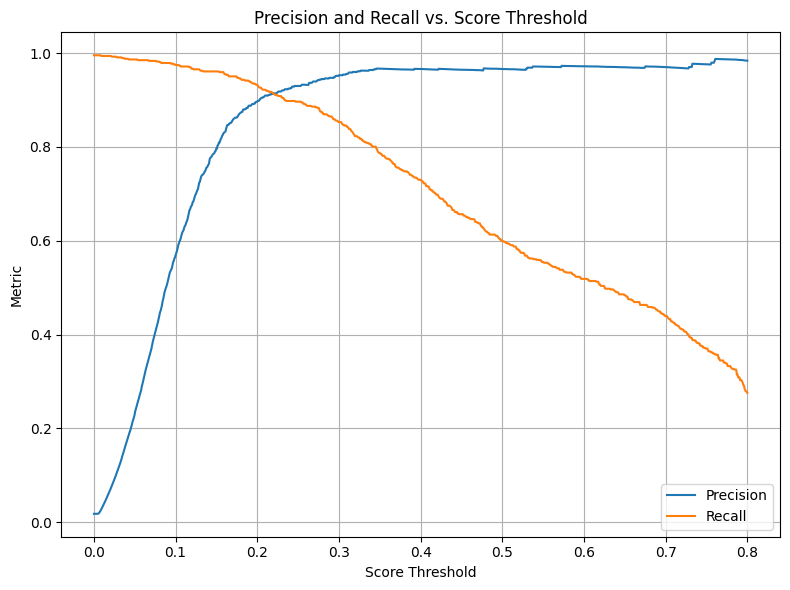

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from cryoet.inference.predict_volume import *
import torch

# Config
score_thresholds_list = np.linspace(0,0.8,1000)
iou_threshold = 0.5
pixel_size = 10.012
box_size = 20
device = 'cuda'
torch_dtype = torch.float16
OUTPUT_DIR = Path(f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_sigma_output/sigma16/{tomo}_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load GT boxes
def read_boxes(filename):
    with open(filename, 'r') as f:
        return [tuple(map(float, line.strip().split())) for line in f]

#ground_truth_boxes = read_boxes('/mnt/data2/D2/generalization_tomogram/coords/gt.coords')
ground_truth_boxes = read_boxes(f'/mnt/data2/D2/generalization_tomogram/coords/gt.coords')

# IoU calculation
def calculate_iou(box1, box2, box_size):
    x1, y1, z1 = box1
    x2, y2, z2 = box2
    x_left = max(x1 - box_size/2, x2 - box_size/2)
    x_right = min(x1 + box_size/2, x2 + box_size/2)
    y_bottom = max(y1 - box_size/2, y2 - box_size/2)
    y_top = min(y1 + box_size/2, y2 + box_size/2)
    z_front = max(z1 - box_size/2, z2 - box_size/2)
    z_back = min(z1 + box_size/2, z2 + box_size/2)
    if x_left < x_right and y_bottom < y_top and z_front < z_back:
        intersection = (x_right - x_left) * (y_top - y_bottom) * (z_back - z_front)
    else:
        intersection = 0
    union = box_size ** 3 * 2 - intersection
    return intersection / union if union != 0 else 0

# Store metrics
precisions, recalls, picks = [], [], []

# study_sub = predict_volume(
#         volume=volume,
#         study_name='TS_5_4',
#         output_strides=(2,),
#         models=models,
#         window_size=(192, 128, 128),
#         tiles_per_dim=(1, 9, 9),
#         use_weighted_average=True,
#         use_centernet_nms=True,
#         use_single_label_per_anchor=False,
#         pre_nms_top_k=16536*2,
#         use_z_flip_tta=False,
#         use_y_flip_tta=False,
#         use_x_flip_tta=False,
#         score_thresholds=[0],
#         iou_threshold=0.2,
#         batch_size=1,
#         num_workers=0,
#         device=device,
#         torch_dtype=torch_dtype,
#     )

for score_threshold in score_thresholds_list:
 

    # Save and format prediction
    CSV_PATH = OUTPUT_DIR / f"submission_thresh_{score_threshold:.4}.csv"
    study_sub[(study_sub['score']>score_threshold)].to_csv(CSV_PATH, index=False)
    submission = pd.read_csv(CSV_PATH)
    submission[['x', 'y', 'z']] = submission[['x', 'y', 'z']] 

    # Save .coords for one class
    group = submission[(submission["experiment"] == f"{tomo}") & (submission["particle_type"] == "apo-ferritin")]
    coords_file = OUTPUT_DIR / f"{tomo}_{score_threshold:.4f}.coords"
    group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

    # Evaluate
    experimental_boxes = read_boxes(coords_file)
    matched = [False] * len(ground_truth_boxes)
    tp = 0

    for exp_box in experimental_boxes:
        best_iou = 0
        best_index = -1
        for i, gt_box in enumerate(ground_truth_boxes):
            if not matched[i]:
                current_iou = calculate_iou(exp_box, gt_box, box_size)
                if current_iou > best_iou:
                    best_iou = current_iou
                    best_index = i
        if best_iou >= iou_threshold:
            tp += 1
            matched[best_index] = True

    precision = tp / len(experimental_boxes) if experimental_boxes else 0.0
    recall = tp / len(ground_truth_boxes) if ground_truth_boxes else 0.0

    print(f"TP: {tp}, Precision: {precision:.4f}, Recall: {recall:.4f}, threshold: {score_threshold:.4f}")
    precisions.append(precision)
    recalls.append(recall)
    picks.append(len(experimental_boxes))

# Plotting
plt.figure(figsize=(8,6))
plt.plot(score_thresholds_list, precisions, label='Precision')
plt.plot(score_thresholds_list, recalls, label='Recall')
#plt.plot(score_thresholds_list, picks, 's-', label='Num_picks')
plt.xlabel("Score Threshold")
plt.ylabel("Metric")
plt.title("Precision and Recall vs. Score Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [86]:
results_df = pd.DataFrame({
    'score_threshold': score_thresholds_list,
    'precision': precisions,
    'recall': recalls,
    'Picks': picks
})
results_df.to_csv('/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/TS_5_4/threshold_metrics.csv', index=False)


In [280]:
import pandas as pd
from pathlib import Path
OUTPUT_DIR = Path("/mnt/data2/D2/OD/Data/separate_particles/TS_71_8")
#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = "/mnt/data2/D2/TS_71_8.csv"
#study_sub.to_csv(f"{CSV_PATH}", index=False)
submission = pd.read_csv(CSV_PATH)
#pixel_size = 10
#submission[['x', 'y','z']] = submission[['x', 'y','z']] / pixel_size
#submission[['x', 'y','z']] = submission[['x', 'y','z']].astype(int)


grouped = submission.groupby(['experiment', 'particle_type'])
for (experiment_id, particle_type), group in grouped:
        coords_file = OUTPUT_DIR / f"{experiment_id}_{particle_type}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")

Saved .coords files in /mnt/data2/D2/OD/Data/separate_particles/TS_71_8


# Different stuff

In [ ]:
import os
import shutil
import glob

# Source and destination root directories
src_root = "/mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p"
dst_root = "/mnt/data2/D2/Sim_trainingdata/simulations"

# Loop over rounds and tomos
for round_num in range(1, 33):  # 1 to 32
    for tomo_num in range(1, 9):  # 1 to 8
        # Source file
        src_file = os.path.join(
            src_root,
            f"tomo_simulation_round_{round_num}",
            f"tomo_0{tomo_num}",
            "particle_positions.txt"
        )

        # Destination folder pattern with wildcard for timestamp
        dst_pattern = os.path.join(
            dst_root,
            f"tomo_simulation_round_{round_num}",
            "out_sim",
            f"tomo_0{tomo_num}.*"  # match any timestamp
        )

        # Use glob to find the matching directory
        matching_dirs = glob.glob(dst_pattern)

        if not os.path.exists(src_file):
            print(f"Missing source: {src_file}")
            continue

        if not matching_dirs:
            print(f"Missing destination directory for: round {round_num}, tomo {tomo_num}")
            continue

        # Pick the first matching directory (or sort and pick if needed)
        dst_tomo_dir = matching_dirs[0]
        dst_file = os.path.join(dst_tomo_dir, "particle_positions.txt")

        shutil.copy2(src_file, dst_file)
        print(f"Copied: {src_file} -> {dst_file}")


Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_01/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_01.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_02/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_02.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_03/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_03.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simul

: 

In [1057]:
import pandas as pd

alles = pd.read_csv('/mnt/data2/D2/CZI_coords/combined_embeddings_exp/alldatawithout_augmented_withdenoised_ep101_coords0.1/exp1/submission_all.csv')

In [1058]:
alles

,Unnamed: 0,id,experiment,particle_type,x,y,z
0,0,0,TS_1_2,virus-like-particle,603.0,86.2,84.40
1,1,1,TS_1_2,virus-like-particle,230.9,338.2,121.40
2,2,2,TS_1_2,virus-like-particle,236.6,344.2,121.10
3,3,3,TS_90_3,virus-like-particle,464.5,218.2,68.25
4,4,4,TS_90_3,virus-like-particle,331.0,519.0,66.30
...,...,...,...,...,...,...,...
41080,41080,12151,TS_93_5,apo-ferritin,377.5,544.5,145.80
41081,41081,12152,TS_93_5,apo-ferritin,308.5,479.0,154.20
41082,41082,12153,TS_93_5,apo-ferritin,475.8,500.5,135.00
41083,41083,12154,TS_93_5,apo-ferritin,291.2,554.0,52.56


In [1059]:
grouped = alles.groupby(['experiment', 'particle_type'])

In [1060]:
for (experiment, particle_type), group in grouped:
    print(f"Experiment: {experiment}, Particle type: {particle_type}")
    #print(group.head())
    OUTPUT_DIR = Path(f"/mnt/data2/D2/CZI_coords/combined_embeddings_exp/alldatawithout_augmented_withdenoised_ep101_coords0.1/exp1/submission_separate_particles/{experiment}/")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    coords_file = OUTPUT_DIR / f"{particle_type}.coords"
    group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

Experiment: TS_100_3, Particle type: apo-ferritin
Experiment: TS_100_3, Particle type: beta-galactosidase
Experiment: TS_100_3, Particle type: ribosome
Experiment: TS_100_3, Particle type: thyroglobulin
Experiment: TS_100_3, Particle type: virus-like-particle
Experiment: TS_101_5, Particle type: apo-ferritin
Experiment: TS_101_5, Particle type: beta-galactosidase
Experiment: TS_101_5, Particle type: ribosome
Experiment: TS_101_5, Particle type: thyroglobulin
Experiment: TS_101_5, Particle type: virus-like-particle
Experiment: TS_102_2, Particle type: apo-ferritin
Experiment: TS_102_2, Particle type: beta-galactosidase
Experiment: TS_102_2, Particle type: ribosome
Experiment: TS_102_2, Particle type: thyroglobulin
Experiment: TS_102_2, Particle type: virus-like-particle
Experiment: TS_103_4, Particle type: apo-ferritin
Experiment: TS_103_4, Particle type: beta-galactosidase
Experiment: TS_103_4, Particle type: ribosome
Experiment: TS_103_4, Particle type: thyroglobulin
Experiment: TS_10

In [45]:
from pathlib import Path
import numpy as np
for exp , group in grouped:
   print(exp)
   OUTPUT_DIR = Path(f"/mnt/data2/D2/OD/Data/{exp}/coords")
   OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
   coords_file = OUTPUT_DIR / f"{exp}.coords"
   txt_file = OUTPUT_DIR / 'particle_positions.txt'
   group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')
   x = group[['particle_type','x', 'y', 'z']]
   x["f1"] = 'NaN'
   x["f2"] = 'NaN'
   x["f3"] = 'NaN'
   x.to_csv(txt_file, index=False, header=False, sep=',')

TS_5_4
TS_69_2
TS_6_4
TS_6_6
TS_73_6
TS_86_3
TS_99_9


/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

In [41]:
import shutil
from pathlib import Path

# Set your source directory (where the .mrc files are)
source_dir = Path("/mnt/data2/D2/public_czi_tomos")

# Set your base destination directory
destination_base = Path("/mnt/data2/D2/OD/Data")

# Iterate over all .mrc files in the source directory
for mrc_file in source_dir.glob("*.mrc"):
    # Get the filename without extension
    file_stem = mrc_file.stem  # e.g., TS_1_2 from TS_1_2.mrc

    # Define destination path: /mnt/data2/D2/OD/Data/TS_1_2/tomo/
    destination_dir = destination_base / file_stem / "tomo"
    destination_dir.mkdir(parents=True, exist_ok=True)

    # Define full destination file path
    destination_file = destination_dir / mrc_file.name

    # Copy the file
    shutil.copy2(mrc_file, destination_file)

    print(f"Copied {mrc_file} -> {destination_file}")


Copied /mnt/data2/D2/public_czi_tomos/TS_43_9.mrc -> /mnt/data2/D2/OD/Data/TS_43_9/tomo/TS_43_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_53_7.mrc -> /mnt/data2/D2/OD/Data/TS_53_7/tomo/TS_53_7.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_93_9.mrc -> /mnt/data2/D2/OD/Data/TS_93_9/tomo/TS_93_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_1_8.mrc -> /mnt/data2/D2/OD/Data/TS_1_8/tomo/TS_1_8.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_109_2.mrc -> /mnt/data2/D2/OD/Data/TS_109_2/tomo/TS_109_2.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_1_7.mrc -> /mnt/data2/D2/OD/Data/TS_1_7/tomo/TS_1_7.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_102_2.mrc -> /mnt/data2/D2/OD/Data/TS_102_2/tomo/TS_102_2.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_65_9.mrc -> /mnt/data2/D2/OD/Data/TS_65_9/tomo/TS_65_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_48_5.mrc -> /mnt/data2/D2/OD/Data/TS_48_5/tomo/TS_48_5.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_60_7.mrc -> /mnt/data2/D2/OD/Data/TS_60_7/tomo/TS_60_7.mrc


In [48]:
import shutil
from pathlib import Path

base_src = Path("/mnt/data2/D2/Sim_trainingdata/simulations")
base_dst = Path("/mnt/data2/D2/OD/Data")

# Loop over 32 rounds
for i in range(1, 33):
    round_dir = base_src / f"tomo_simulation_round_{i}" / "out_sim"

    # Loop over 8 tomograms per round
    for j in range(1, 9):
        tomo_prefix = f"tomo_{j:02d}"

        # Search for folder starting with "tomo_{j:02d}."
        matches = list(round_dir.glob(f"{tomo_prefix}.*"))
        if not matches:
            print(f"[!] No folder found for {tomo_prefix} in round {i}")
            continue

        tomo_dir = matches[0]  # Assume first match is the correct one
        mrc_file = tomo_dir / "reconstruction" / "tiltseries_rec.mrc"
        txt_file = tomo_dir / "particle_positions.txt"
        if not mrc_file.exists():
            print(f"[!] MRC file not found: {mrc_file}")
            continue

        # Destination path
        dst_dir = base_dst / f"round{i}_tomo{j}" / "tomo"
        dst_dir.mkdir(parents=True, exist_ok=True)

        coordspath = base_dst / f"round{i}_tomo{j}" / "coords"
        coordspath.mkdir(parents=True, exist_ok=True)
        # Copy file
        dst_file = dst_dir / "tiltseries_rec.mrc"
        co = coordspath / "particle_positions.txt"

        shutil.copy2(mrc_file, dst_file)
        shutil.copy2(txt_file, co)

        print(f"[✓] Copied: {mrc_file} -> {dst_file}")


[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_01.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo1/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_02.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo2/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_03.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo3/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_04.2022-04-11T17:02:38+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo4/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_05.2022-04-11T17:02:38+02:00/reconstruct

In [ ]:
os.listdir('/mnt/data2/D2/OD/Data/train')

['TS_98_1', 'round23_tomo4']

: 

In [2]:
# get coords for every particle alone
import pandas as pd
from pathlib import Path
import numpy as np

alles = pd.read_csv('/mnt/data2/D2/10445/all_gt_repeated.csv')

grouped = alles.groupby(['experiment', 'particle_type'])

for (experiment_id, particle_type), group in grouped:
        OUTPUT_DIR = Path(f"/mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/CZI_Picking_Competition/debugging_after_ariana/GT_separate_particles/{experiment_id}/")
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        coords_file = OUTPUT_DIR / f"{particle_type}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')


In [106]:
import os
for file in os.listdir('/mnt/data2/D2/OD/Data/validation'):
    if 'TS' in file:
        c_path = f'/mnt/data2/D2/OD/Data/validation/{file}/coords/{file}.coords'
        with open(c_path, "r") as f:
            lines = f.readlines()

        with open(c_path, "w") as f:
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 3:
                    continue  # skip lines that don't have exactly 3 values
                x, y, z = map(float, parts)
                f.write(f"{x * 10 /10.012} {y * 10/ 10.012} {z * 10/10.012}\n")
        

In [ ]:
import os
for file in os.listdir('/mnt/data2/D2/OD/Data/validation'):
    if 'TS' in file:
        c_path = f'/mnt/data2/D2/OD/Data/validation/{file}/coords/particle_positions.txt'
        with open(c_path, "r") as f:
            lines = f.readlines()

        with open(c_path, "w") as f:
            for line in lines:
                parts = line.strip().split(",")
                if len(parts) < 4:
                    continue  # malformed line
                name = parts[0]
                x, y, z = map(float, parts[1:4])
                parts[1] = str(x * 10/10.012)
                parts[2] = str(y * 10/10.012)
                parts[3] = str(z * 10/10.012)
                f.write(",".join(parts) + "\n")

: 

In [151]:
p = '/mnt/data2/D2/OD/Data/extra/round11_tomo7/coords/particle_positions.txt'
c = '/mnt/data2/D2/OD/Data/extra/round11_tomo7/coords/round11_tomo7.coords'
with open(p, "r") as f:
    lines = f.readlines()
with open(c,'w') as f:
    for line in lines:
        parts = line.strip().split(",")
        x , y, z = map(float, parts[1:4])
        f.write(f"{x} {y} {z}\n")


In [112]:
from pathlib import Path
import numpy as np
for exp , group in grouped:
   print(exp)
   #OUTPUT_DIR = Path(f"/mnt/data2/D2/OD/Data/{exp}/coords")
   #OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
   #coords_file = OUTPUT_DIR / f"{exp}.coords"
   if exp not in os.listdir('/mnt/data2/D2/OD/Data/train'):
      continue
   txt_file = f'/mnt/data2/D2/OD/Data/train/{exp}/coords/particle_positions.txt'
   #group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')
   x = group[['particle_type','x', 'y', 'z']]
   x["f1"] = 'NaN'
   x["f2"] = 'NaN'
   x["f3"] = 'NaN'
   x.to_csv(txt_file, index=False, header=False, sep=',')

TS_100_3
TS_101_5
TS_102_2
TS_103_4
TS_103_5


/tmp/ipykernel_1298067/1054006766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'


TS_105_5
TS_105_7
TS_106_7
TS_107_1
TS_109_2
TS_109_3
TS_109_5
TS_111_2
TS_112_6
TS_114_4
TS_115_4
TS_115_7
TS_11_7
TS_12_3
TS_12_9
TS_13_9
TS_14_1
TS_14_2
TS_14_4
TS_14_6
TS_15_1
TS_1_2
TS_1_3
TS_1_4
TS_1_5
TS_1_7
TS_1_8
TS_25_6
TS_27_1
TS_27_7
TS_2_3
TS_30_2
TS_31_8
TS_33_4
TS_37_1
TS_37_8
TS_43_9
TS_44_4
TS_45_1
TS_46_8
TS_47_2
TS_47_7
TS_48_5
TS_4_3
TS_52_3
TS_53_7
TS_58_6
TS_58_7
TS_58_9
TS_59_1
TS_59_8
TS_5_2
TS_5_8
TS_60_6
TS_60_7
TS_60_8
TS_63_6
TS_63_7
TS_65_4
TS_65_8
TS_65_9
TS_67_2
TS_67_3
TS_67_6
TS_67_7
TS_68_4
TS_68_7
TS_6_7
TS_70_8
TS_70_9
TS_71_3
TS_71_7
TS_71_8
TS_74_1
TS_74_3
TS_74_8
TS_76_3
TS_76_4
TS_76_8
TS_79_4
TS_80_5
TS_80_8
TS_81_1
TS_81_4
TS_83_1
TS_84_5
TS_84_7
TS_85_1
TS_86_4
TS_86_8
TS_86_9
TS_87_4
TS_87_5
TS_87_6
TS_87_7
TS_88_3
TS_89_2
TS_89_5
TS_90_2
TS_90_3
TS_90_4
TS_91_7
TS_91_9
TS_93_5
TS_93_9
TS_94_3
TS_94_5
TS_94_6
TS_94_7
TS_96_4
TS_96_9
TS_97_7
TS_98_1
TS_98_4
TS_9_2
TS_9_3


/tmp/ipykernel_1298067/1054006766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1298067/1054006766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1298067/1054006766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

In [ ]:
def as_tuple_of_3(value) -> Tuple:
    if isinstance(value, (int, float)):
        result = value, value, value
    else:
        a, b, c = value
        result = a, b, c

    return result


def compute_better_tiles_1d_yousef(length: int, window_size: int, step:int, num_tiles: int):
    """
    Compute the slices for a sliding window over a one dimension.
    Method distribute tiles evenly over the length such that first tile is [0, window_size), and last tile is [length-window_size, length).
    """
    starts = np.arange(num_tiles) * (window_size - step)
    ends = np.minimum(starts + window_size , length)
    for start, end in zip(starts, ends):
        yield slice(start, end)


In [ ]:
def compute_better_tiles_yousef(
    volume_shape: Tuple[int, int, int],
    window_size: Union[int, Tuple[int, int, int]],
    window_step: Union[int, Tuple[int, int, int]],
) -> Iterable[Tuple[slice, slice, slice]]:
    """Compute the slices for a sliding window over a volume.
    A method can output a last slice that is smaller than the window size.
    """
    window_size_z, window_size_y, window_size_x = as_tuple_of_3(window_size)
    window_step_z, window_step_y, window_step_x = as_tuple_of_3(window_step)
    z, y, x = volume_shape

    num_z_tiles = math.ceil(z / (window_size_z - window_step_z))
    num_y_tiles = math.ceil(y / (window_size_y - window_step_y))
    num_x_tiles = math.ceil(x / (window_size_x - window_step_x))

    for z_slice in compute_better_tiles_1d(z, window_size_z,window_step_z, num_z_tiles):
        for y_slice in compute_better_tiles_1d(y, window_size_y,window_step_y, num_y_tiles):
            for x_slice in compute_better_tiles_1d(x, window_size_x,window_step_x, num_x_tiles):
                yield (
                    z_slice,
                    y_slice,
                    x_slice,
                )

In [66]:
tiles = compute_better_tiles(volume_shape=(512,1024,1024),window_size=(512,256,256),window_step=(10,10,10))

In [67]:
for tile in tiles:
    print(tile)

(slice(0, 512, None), slice(0, 256, None), slice(0, 256, None))
(slice(0, 512, None), slice(0, 256, None), slice(246, 502, None))
(slice(0, 512, None), slice(0, 256, None), slice(492, 748, None))
(slice(0, 512, None), slice(0, 256, None), slice(738, 994, None))
(slice(0, 512, None), slice(0, 256, None), slice(984, 1024, None))
(slice(0, 512, None), slice(246, 502, None), slice(0, 256, None))
(slice(0, 512, None), slice(246, 502, None), slice(246, 502, None))
(slice(0, 512, None), slice(246, 502, None), slice(492, 748, None))
(slice(0, 512, None), slice(246, 502, None), slice(738, 994, None))
(slice(0, 512, None), slice(246, 502, None), slice(984, 1024, None))
(slice(0, 512, None), slice(492, 748, None), slice(0, 256, None))
(slice(0, 512, None), slice(492, 748, None), slice(246, 502, None))
(slice(0, 512, None), slice(492, 748, None), slice(492, 748, None))
(slice(0, 512, None), slice(492, 748, None), slice(738, 994, None))
(slice(0, 512, None), slice(492, 748, None), slice(984, 1024, 